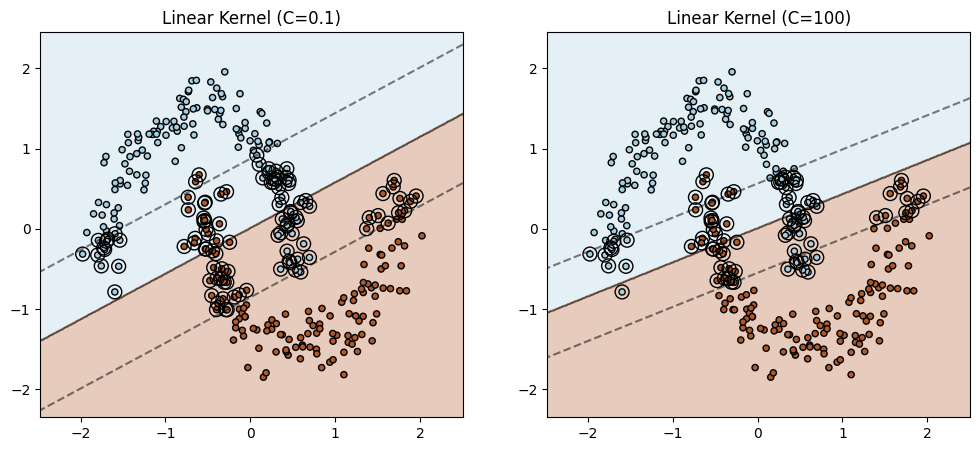

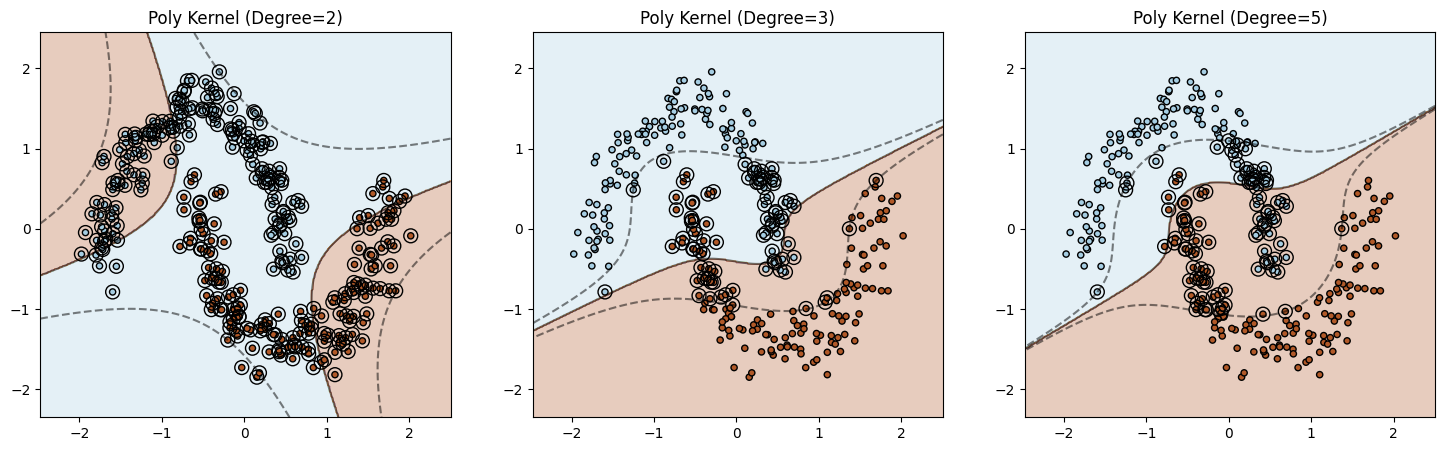

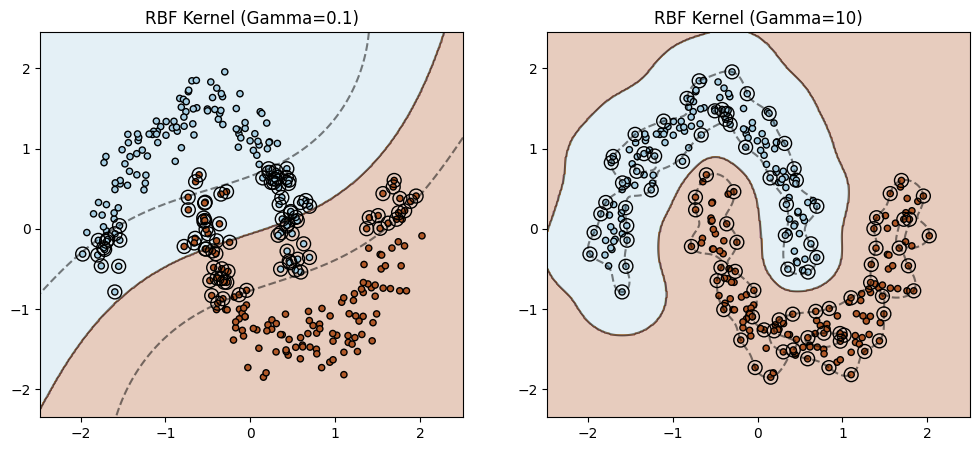

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, svm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time

# Generate non-linearly separable datasets
def get_datasets():
    n_samples = 300
    # Moons
    moons = datasets.make_moons(n_samples=n_samples, noise=0.1, random_state=42)
    # Circles
    circles = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.1, random_state=42)
    # XOR
    xx, yy = np.meshgrid(np.linspace(-3, 3, 20), np.linspace(-3, 3, 20))
    X_xor = np.random.randn(n_samples, 2)
    y_xor = np.logical_xor(X_xor[:, 0] > 0, X_xor[:, 1] > 0).astype(int)
    xor = (X_xor, y_xor)

    return {"Moons": moons, "Circles": circles, "XOR": xor}
def plot_svm_boundary(clf, X, y, ax, title):
    # Create meshgrid
    h = .02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict and Plot Contours
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.3)

    # Plot Decision Function (Margins)
    P = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    P = P.reshape(xx.shape)
    ax.contour(xx, yy, P, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

    # Scatter plot data and highlight Support Vectors
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired, edgecolors='k', s=20)
    ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
               s=100, linewidth=1, facecolors='none', edgecolors='k', label='Support Vectors')
    ax.set_title(title)

data_dict = get_datasets()
X, y = data_dict["Moons"]
X = StandardScaler().fit_transform(X) # SVMs are sensitive to scale

# 1. Linear Kernel - Effect of C (Penalty parameter)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, C in enumerate([0.1, 100]):
    clf = svm.SVC(kernel='linear', C=C).fit(X, y)
    plot_svm_boundary(clf, X, y, axes[i], f"Linear Kernel (C={C})")

# 2. Polynomial Kernel - Degrees (2, 3, 5)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, d in enumerate([2, 3, 5]):
    clf = svm.SVC(kernel='poly', degree=d, C=1.0).fit(X, y)
    plot_svm_boundary(clf, X, y, axes[i], f"Poly Kernel (Degree={d})")

# 3. RBF Kernel - Gamma parameter
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, g in enumerate([0.1, 10]):
    clf = svm.SVC(kernel='rbf', gamma=g, C=1.0).fit(X, y)
    plot_svm_boundary(clf, X, y, axes[i], f"RBF Kernel (Gamma={g})")

plt.show()

In [5]:
import numpy as np
from sklearn import svm, datasets

# A simple custom linear kernel: k(x, y) = x * M * y.T
def my_custom_kernel(X1, X2):
    # Transformation matrix M
    M = np.array([[2, 0], [0, 1.0]])
    return np.dot(np.dot(X1, M), X2.T)

# Usage
iris = datasets.load_iris()
X, y = iris.data[:, :2], iris.target
clf = svm.SVC(kernel=my_custom_kernel)
clf.fit(X, y)
print(f"Custom Kernel Accuracy: {clf.score(X, y):.2f}")

from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.svm import LinearSVC

# One-vs-Rest (Common for large datasets)
ovr_clf = OneVsRestClassifier(LinearSVC(random_state=42)).fit(X, y)

# One-vs-One (Often more robust for small datasets)
ovo_clf = OneVsOneClassifier(LinearSVC(random_state=42)).fit(X, y)

print(f"OvR Score: {ovr_clf.score(X, y):.2f} | OvO Score: {ovo_clf.score(X, y):.2f}")
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'poly', 'sigmoid']
}

grid = GridSearchCV(svm.SVC(), param_grid, refit=True, verbose=0, cv=5)
grid.fit(X, y)

print(f"Best Parameters: {grid.best_params_}")
print(f"Best Cross-Validation Score: {grid.best_score_:.2f}")

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# 1. Without Scaling
clf_raw = svm.SVC().fit(X, y)
acc_raw = accuracy_score(y, clf_raw.predict(X))

# 2. With Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
clf_scaled = svm.SVC().fit(X_scaled, y)
acc_scaled = accuracy_score(y, clf_scaled.predict(X_scaled))

print(f"Accuracy (No Scaling): {acc_raw:.2f}")
print(f"Accuracy (With Scaling): {acc_scaled:.2f}")

Custom Kernel Accuracy: 0.83
OvR Score: 0.80 | OvO Score: 0.80
Best Parameters: {'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.82
Accuracy (No Scaling): 0.82
Accuracy (With Scaling): 0.82
